# Travel Industry ML & MLOps — Flight Price Prediction

This notebook develops the Flight Price Prediction module of the Travel Industry ML & MLOps project.

## Workflow

1. Load the flight dataset
2. Explore and understand the data
3. Perform data cleaning and validation
4. Exploratory Data Analysis (EDA)
5. Feature engineering
6. Data preprocessing
7. Train multiple regression models
8. Evaluate and compare models
9. Select the best-performing model
10. Prepare the final model pipeline for MLflow and deployment

In [1]:
# ==============================
# Core Libraries
# ==============================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ==============================
# MLflow Configuration
# ==============================

import mlflow

MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

mlflow.set_experiment(
    "Voyage Analytics - Flight Price Prediction"
)

print("MLflow:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())

MLflow: 3.15.1
Tracking URI: http://127.0.0.1:5000


In [12]:
# ==============================
# Project Paths
# ==============================

from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "travel_capstone_dataset"

FLIGHTS_PATH = DATA_DIR / "flights.csv"

print("Project directory:", BASE_DIR)
print("Flights dataset:", FLIGHTS_PATH)
print("Dataset exists:", FLIGHTS_PATH.exists())

Project directory: c:\Users\VINAY\Desktop\Labmentix Projects\Travel_MLops_Major_Project
Flights dataset: c:\Users\VINAY\Desktop\Labmentix Projects\Travel_MLops_Major_Project\travel_capstone_dataset\flights.csv
Dataset exists: True


In [13]:
# ==============================
# Load Flight Dataset
# ==============================

import pandas as pd

df = pd.read_csv(FLIGHTS_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 271,888
Columns: 10


In [14]:
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


## 1. Dataset Overview

In [15]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [16]:
# Missing values
df.isnull().sum()

travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

In [17]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
# Basic numerical statistics
df.describe()

,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


In [19]:
# Unique values in categorical columns
categorical_cols = ["from", "to", "flightType", "agency"]

for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].unique()[:20])


from: 9 unique values
['Recife (PE)' 'Florianopolis (SC)' 'Brasilia (DF)' 'Aracaju (SE)'
 'Salvador (BH)' 'Campo Grande (MS)' 'Sao Paulo (SP)' 'Natal (RN)'
 'Rio de Janeiro (RJ)']

to: 9 unique values
['Florianopolis (SC)' 'Recife (PE)' 'Brasilia (DF)' 'Salvador (BH)'
 'Aracaju (SE)' 'Campo Grande (MS)' 'Sao Paulo (SP)' 'Natal (RN)'
 'Rio de Janeiro (RJ)']

flightType: 3 unique values
['firstClass' 'economic' 'premium']

agency: 3 unique values
['FlyingDrops' 'CloudFy' 'Rainbow']


In [20]:
# Average and median price by categorical features

for col in ["flightType", "agency"]:
    print(f"\n--- Price by {col} ---")
    print(
        df.groupby(col)["price"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(2)
    )


--- Price by flightType ---
             count     mean   median     min      max
flightType                                           
economic     77466   658.44   674.52  301.51   972.12
firstClass  116418  1181.07  1190.94  539.39  1754.17
premium      78004   920.39   932.84  427.25  1370.17

--- Price by agency ---
              count     mean   median     min      max
agency                                                
CloudFy      116378   918.90   883.63  301.51  1747.31
FlyingDrops   38758  1186.16  1269.73  539.39  1744.87
Rainbow      116752   919.78   870.91  301.61  1754.17


In [21]:
# Most common routes and their price statistics

route_stats = (
    df.groupby(["from", "to"])["price"]
    .agg(["count", "mean", "median"])
    .sort_values("count", ascending=False)
)

route_stats.head(15).round(2)

count     mean   median
from                to                                          
Florianopolis (SC)  Aracaju (SE)          8643  1246.37  1248.70
Aracaju (SE)        Florianopolis (SC)    8643  1232.44  1174.97
Campo Grande (MS)   Florianopolis (SC)    8253  1106.75  1031.59
Florianopolis (SC)  Campo Grande (MS)     8253   740.47   714.86
Brasilia (DF)       Florianopolis (SC)    7779  1260.25  1222.24
Florianopolis (SC)  Brasilia (DF)         7779   886.55   885.37
Recife (PE)         Florianopolis (SC)    7609  1122.36  1074.75
Florianopolis (SC)  Recife (PE)           7609  1007.67  1013.40
                    Sao Paulo (SP)        6717   597.69   577.76
Sao Paulo (SP)      Florianopolis (SC)    6717  1380.88  1370.17
Florianopolis (SC)  Natal (RN)            6709  1115.30  1128.51
Natal (RN)          Florianopolis (SC)    6709  1258.46  1212.58
Rio de Janeiro (RJ) Florianopolis (SC)    5807   741.31   708.27
Florianopolis (SC)  Rio de Janeiro (RJ)   5807   474.81   481.42
Salvador (BH)       Florianopolis (SC)    5800  1346.09  1336.68

In [22]:
# Correlation between numerical variables

numeric_cols = ["travelCode", "userCode", "price", "time", "distance"]

df[numeric_cols].corr().round(3)

,travelCode,userCode,price,time,distance
travelCode,1.000,1.000,0.136,0.311,0.311
userCode,1.000,1.000,0.137,0.314,0.314
price,0.136,0.137,1.000,0.642,0.642
time,0.311,0.314,0.642,1.000,1.000
distance,0.311,0.314,0.642,1.000,1.000


## 3. Date Feature Analysis

In [24]:
# Convert date to datetime

df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y")

print("Date range:")
print("Start:", df["date"].min())
print("End:", df["date"].max())

Date range:
Start: 2019-09-26 00:00:00
End: 2023-07-24 00:00:00


In [25]:
# Create temporary date features for analysis

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

print(df[["date", "year", "month", "day", "day_of_week"]].head())

        date  year  month  day  day_of_week
0 2019-09-26  2019      9   26            3
1 2019-09-30  2019      9   30            0
2 2019-10-03  2019     10    3            3
3 2019-10-04  2019     10    4            4
4 2019-10-10  2019     10   10            3


In [26]:
print("Years:")
print(df["year"].value_counts().sort_index())

print("\nMonths:")
print(df["month"].value_counts().sort_index())

print("\nDays of week:")
print(df["day_of_week"].value_counts().sort_index())

Years:
year
2019     35826
2020    112571
2021     75363
2022     41761
2023      6367
Name: count, dtype: int64

Months:
month
1     25587
2     22387
3     22741
4     22607
5     20968
6     19061
7     20113
8     17866
9     19468
10    28980
11    25764
12    26346
Name: count, dtype: int64

Days of week:
day_of_week
0     34108
3    135944
4     33880
5     33868
6     34088
Name: count, dtype: int64


## 4. Feature Engineering

In [27]:
# ==============================
# Feature Engineering
# ==============================

model_df = df.copy()

# Date-derived features
model_df["year"] = model_df["date"].dt.year
model_df["month"] = model_df["date"].dt.month
model_df["day"] = model_df["date"].dt.day
model_df["day_of_week"] = model_df["date"].dt.dayofweek

# Remove columns that are identifiers / not useful for generalization
model_df = model_df.drop(columns=["travelCode", "userCode", "date"])

print("Model dataset shape:", model_df.shape)
model_df.head()

Model dataset shape: (271888, 11)


,from,to,flightType,price,time,distance,agency,year,month,day,day_of_week
0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019,9,26,3
1,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019,9,30,0
2,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019,10,3,3
3,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019,10,4,4
4,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019,10,10,3


## 5. Define X and y

In [30]:
# ==============================
# Features and Target
# ==============================

X = model_df.drop(columns=["price"])
y = model_df["price"]

print("Features:", X.columns.tolist())
print("Target:", y.name)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['from', 'to', 'flightType', 'time', 'distance', 'agency', 'year', 'month', 'day', 'day_of_week']
Target: price
X shape: (271888, 10)
y shape: (271888,)


## 6. Data Preprocessing Pipeline

Categorical features are encoded using One-Hot Encoding, while numerical features are passed through the preprocessing pipeline.

The preprocessing pipeline will later be combined with the trained regression model so that the exact same transformations can be applied during API-based prediction.

In [32]:
# ==============================
# Preprocessing Pipeline
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "from",
    "to",
    "flightType",
    "agency"
]

numerical_features = [
    "time",
    "distance",
    "year",
    "month",
    "day",
    "day_of_week"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 7. Train/Test Split

A time-based split is used to simulate a real-world scenario where historical flight data is used to predict prices for future dates.

- Training data: 2019–2022
- Test data: 2023

In [33]:
# ==============================
# Time-Based Train/Test Split
# ==============================

train_mask = df["date"].dt.year < 2023
test_mask = df["date"].dt.year == 2023

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print(
    "Training period:",
    df.loc[train_mask, "date"].min().date(),
    "to",
    df.loc[train_mask, "date"].max().date()
)

print(
    "Testing period :",
    df.loc[test_mask, "date"].min().date(),
    "to",
    df.loc[test_mask, "date"].max().date()
)

Training samples: 265521
Testing samples : 6367
Training period: 2019-09-26 to 2022-12-31
Testing period : 2023-01-01 to 2023-07-24


In [34]:
# ==============================
# Define Features and Target
# ==============================

X = model_df.drop(columns=["price"])
y = model_df["price"]

print("Features:", X.columns.tolist())
print("Target:", y.name)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['from', 'to', 'flightType', 'time', 'distance', 'agency', 'year', 'month', 'day', 'day_of_week']
Target: price
X shape: (271888, 10)
y shape: (271888,)


## 8. Baseline Model

Linear Regression is used as the baseline regression model. More advanced models will be compared against this baseline using MAE, RMSE, and R².

In [35]:
# ==============================
# Baseline Model
# ==============================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Baseline pipeline created successfully.")

Baseline pipeline created successfully.


In [36]:
# Train baseline model

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [37]:
# Predictions

y_pred_baseline = baseline_model.predict(X_test)

print("Predictions generated:", len(y_pred_baseline))

Predictions generated: 6367


In [38]:
# ==============================
# Baseline Evaluation
# ==============================

mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Model Performance")
print("-" * 40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Baseline Model Performance
----------------------------------------
MAE  : 80.14
RMSE : 101.69
R²   : 0.9211


## 9. Tree-Based Model — Random Forest

Random Forest is evaluated as a nonlinear ensemble model to determine whether it can improve upon the Linear Regression baseline.

In [39]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [40]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [41]:
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated:", len(y_pred_rf))

Predictions generated: 6367


In [42]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 40)
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
----------------------------------------
MAE  : 0.04
RMSE : 0.47
R²   : 1.0000


In [43]:
# ==============================
# Random Forest Error Analysis
# ==============================

results = X_test.copy()

results["actual_price"] = y_test
results["predicted_price"] = y_pred_rf
results["error"] = results["actual_price"] - results["predicted_price"]
results["absolute_error"] = results["error"].abs()

results[[
    "actual_price",
    "predicted_price",
    "error",
    "absolute_error"
]].head(20)

,actual_price,predicted_price,error,absolute_error
793,1664.01,1664.0100,-6.366463e-12,6.366463e-12
794,432.10,432.1000,-1.307399e-12,1.307399e-12
795,393.68,393.6800,2.842171e-13,2.842171e-13
796,1038.95,1038.9500,0.000000e+00,0.000000e+00
797,1262.23,1262.2300,1.818989e-12,1.818989e-12
798,1116.83,1116.8300,2.728484e-12,2.728484e-12
799,1146.95,1146.9500,9.094947e-13,9.094947e-13
800,932.22,932.2200,0.000000e+00,0.000000e+00
801,875.41,875.4100,1.705303e-12,1.705303e-12
802,301.51,301.5100,1.080025e-12,1.080025e-12


In [44]:
print("Maximum absolute error:",
      results["absolute_error"].max())

print("Median absolute error:",
      results["absolute_error"].median())

print("Mean absolute error:",
      results["absolute_error"].mean())

Maximum absolute error: 10.385200000000395
Median absolute error: 2.2737367544323206e-12
Mean absolute error: 0.04114191927457387


In [45]:
# ==============================
# Check Feature Combination Overlap
# ==============================

feature_check_cols = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency"
]

train_combinations = set(
    map(tuple, X_train[feature_check_cols].to_numpy())
)

test_combinations = list(
    map(tuple, X_test[feature_check_cols].to_numpy())
)

overlap_count = sum(
    combo in train_combinations
    for combo in test_combinations
)

print("Test rows:", len(test_combinations))
print("Test combinations already seen in training:", overlap_count)
print(
    "Overlap percentage:",
    round(overlap_count / len(test_combinations) * 100, 2),
    "%"
)

Test rows: 6367
Test combinations already seen in training: 6367
Overlap percentage: 100.0 %


In [46]:
# Check whether identical feature combinations have identical prices

group_cols = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency"
]

price_variation = (
    df.groupby(group_cols)["price"]
      .agg(["count", "nunique", "min", "max"])
      .reset_index()
)

print(price_variation["nunique"].value_counts().head())

nunique
1    490
Name: count, dtype: int64


In [47]:
print(
    "Groups with exactly one unique price:",
    (price_variation["nunique"] == 1).sum()
)

print(
    "Total groups:",
    len(price_variation)
)

Groups with exactly one unique price: 490
Total groups: 490


## 10. Group-Based Validation

The dataset contains repeated flight configurations across different dates. A time-based split alone allows the same feature combinations to appear in both training and testing data. To evaluate genuine generalization, we therefore create groups based on the flight configuration and ensure that the same configuration does not appear in both sets.

In [48]:
# ==============================
# Create Flight Configuration Groups
# ==============================

group_columns = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency"
]

df["flight_group"] = (
    df[group_columns]
    .astype(str)
    .agg(" | ".join, axis=1)
)

print("Total unique flight configurations:", df["flight_group"].nunique())

Total unique flight configurations: 490


## 10.1 Create a group-based train/test split

In [49]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        model_df,
        y,
        groups=df["flight_group"]
    )
)

X_group_train = X.iloc[train_idx]
X_group_test = X.iloc[test_idx]

y_group_train = y.iloc[train_idx]
y_group_test = y.iloc[test_idx]

groups_train = df["flight_group"].iloc[train_idx]
groups_test = df["flight_group"].iloc[test_idx]

print("Training samples:", len(X_group_train))
print("Testing samples :", len(X_group_test))
print("Training groups :", groups_train.nunique())
print("Testing groups  :", groups_test.nunique())

Training samples: 221274
Testing samples : 50614
Training groups : 392
Testing groups  : 98


In [50]:
overlap = set(groups_train).intersection(set(groups_test))

print("Group overlap:", len(overlap))

Group overlap: 0


In [51]:
random_forest_group = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_group.fit(
    X_group_train,
    y_group_train
)

y_pred_rf_group = random_forest_group.predict(
    X_group_test
)

In [52]:
mae_rf_group = mean_absolute_error(
    y_group_test,
    y_pred_rf_group
)

rmse_rf_group = np.sqrt(
    mean_squared_error(
        y_group_test,
        y_pred_rf_group
    )
)

r2_rf_group = r2_score(
    y_group_test,
    y_pred_rf_group
)

print("Random Forest — Unseen Configuration Evaluation")
print("-" * 50)
print(f"MAE  : {mae_rf_group:.2f}")
print(f"RMSE : {rmse_rf_group:.2f}")
print(f"R²   : {r2_rf_group:.4f}")

Random Forest — Unseen Configuration Evaluation
--------------------------------------------------
MAE  : 54.61
RMSE : 70.55
R²   : 0.9575


## 11. XGBoost Regression

XGBoost is evaluated as a gradient-boosting regression model on the same group-based train/test split used for Random Forest.

The objective is to determine whether boosting can improve prediction performance while maintaining genuine generalization to previously unseen flight configurations.

## 11.1 Check XGBoost

In [54]:
# ==============================
# XGBoost Availability
# ==============================

try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("XGBoost is not installed.")

XGBoost version: 3.4.1


## 11.2 Build the XGBoost pipeline

In [55]:
# ==============================
# XGBoost Model
# ==============================

from xgboost import XGBRegressor

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                min_child_weight=1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


## 11.3 Train

In [56]:
# ==============================
# Train XGBoost
# ==============================

xgb_model.fit(
    X_group_train,
    y_group_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## 11.4 Predict

In [57]:
y_pred_xgb = xgb_model.predict(X_group_test)

print("Predictions generated:", len(y_pred_xgb))

Predictions generated: 50614


## 11.5 Evaluate

In [60]:
# ==============================
# XGBoost Evaluation
# ==============================

mae_xgb = mean_absolute_error(
    y_group_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_group_test,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_group_test,
    y_pred_xgb
)

print("XGBoost — Unseen Configuration Evaluation")
print("-" * 50)
print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"R²   : {r2_xgb:.4f}")

XGBoost — Unseen Configuration Evaluation
--------------------------------------------------
MAE  : 44.45
RMSE : 55.65
R²   : 0.9735


In [61]:
# ==============================
# Model Comparison
# ==============================

model_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "MAE": mae_rf_group,
        "RMSE": rmse_rf_group,
        "R2": r2_rf_group
    },
    {
        "Model": "XGBoost",
        "MAE": mae_xgb,
        "RMSE": rmse_xgb,
        "R2": r2_xgb
    }
])

model_results.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,XGBoost,44.451849,55.646714,0.973533
0,Random Forest,54.614140,70.550960,0.957456


## 12. Build model comparison

In [62]:
# ==============================
# Model Comparison
# ==============================

model_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "MAE": mae_rf_group,
        "RMSE": rmse_rf_group,
        "R2": r2_rf_group
    },
    {
        "Model": "XGBoost",
        "MAE": mae_xgb,
        "RMSE": rmse_xgb,
        "R2": r2_xgb
    }
])

model_results.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,XGBoost,44.451849,55.646714,0.973533
0,Random Forest,54.614140,70.550960,0.957456


In [64]:
# ==============================
# Linear Regression — Group Split
# ==============================

baseline_group = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

baseline_group.fit(
    X_group_train,
    y_group_train
)

y_pred_lr_group = baseline_group.predict(
    X_group_test
)

mae_lr_group = mean_absolute_error(
    y_group_test,
    y_pred_lr_group
)

rmse_lr_group = np.sqrt(
    mean_squared_error(
        y_group_test,
        y_pred_lr_group
    )
)

r2_lr_group = r2_score(
    y_group_test,
    y_pred_lr_group
)

print("Linear Regression — Unseen Configuration Evaluation")
print("-" * 55)
print(f"MAE  : {mae_lr_group:.2f}")
print(f"RMSE : {rmse_lr_group:.2f}")
print(f"R²   : {r2_lr_group:.4f}")

Linear Regression — Unseen Configuration Evaluation
-------------------------------------------------------
MAE  : 82.13
RMSE : 100.01
R²   : 0.9145


In [65]:
# ==============================
# Model Comparison - Group Split
# ==============================

model_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae_lr_group,
        "RMSE": rmse_lr_group,
        "R2": r2_lr_group
    },
    {
        "Model": "Random Forest",
        "MAE": mae_rf_group,
        "RMSE": rmse_rf_group,
        "R2": r2_rf_group
    },
    {
        "Model": "XGBoost",
        "MAE": mae_xgb,
        "RMSE": rmse_xgb,
        "R2": r2_xgb
    }
])

model_results = (
    model_results
    .sort_values("RMSE")
    .reset_index(drop=True)
    .round(4)
)

model_results

,Model,MAE,RMSE,R2
0,XGBoost,44.4518,55.6467,0.9735
1,Random Forest,54.6141,70.5510,0.9575
2,Linear Regression,82.1309,100.0069,0.9145


## 13. LightGBM Regression

LightGBM is evaluated on the same unseen flight-configuration split to provide a fair comparison with XGBoost and Random Forest.

In [66]:
try:
    import lightgbm as lgb
    print("LightGBM version:", lgb.__version__)
except ImportError:
    print("LightGBM is not installed.")

LightGBM version: 4.7.0


## Step 12.1 — LightGBM pipeline

In [67]:
# ==============================
# LightGBM Model
# ==============================

from lightgbm import LGBMRegressor

lgbm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=-1,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

print("LightGBM pipeline created successfully.")

LightGBM pipeline created successfully.


## 12.2  Train

In [68]:
# ==============================
# Train LightGBM
# ==============================

lgbm_model.fit(
    X_group_train,
    y_group_train
)

print("LightGBM model trained successfully.")

LightGBM model trained successfully.


## 12.3 Predict

In [69]:
y_pred_lgbm = lgbm_model.predict(X_group_test)

print("Predictions generated:", len(y_pred_lgbm))

Predictions generated: 50614


## 12.4  Evaluate

In [70]:
# ==============================
# LightGBM Evaluation
# ==============================

mae_lgbm = mean_absolute_error(
    y_group_test,
    y_pred_lgbm
)

rmse_lgbm = np.sqrt(
    mean_squared_error(
        y_group_test,
        y_pred_lgbm
    )
)

r2_lgbm = r2_score(
    y_group_test,
    y_pred_lgbm
)

print("LightGBM — Unseen Configuration Evaluation")
print("-" * 55)
print(f"MAE  : {mae_lgbm:.2f}")
print(f"RMSE : {rmse_lgbm:.2f}")
print(f"R²   : {r2_lgbm:.4f}")

LightGBM — Unseen Configuration Evaluation
-------------------------------------------------------
MAE  : 41.73
RMSE : 52.48
R²   : 0.9765


## 12.5  Final comparison of the four models

In [71]:
# ==============================
# Four-Model Comparison
# ==============================

model_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae_lr_group,
        "RMSE": rmse_lr_group,
        "R2": r2_lr_group
    },
    {
        "Model": "Random Forest",
        "MAE": mae_rf_group,
        "RMSE": rmse_rf_group,
        "R2": r2_rf_group
    },
    {
        "Model": "XGBoost",
        "MAE": mae_xgb,
        "RMSE": rmse_xgb,
        "R2": r2_xgb
    },
    {
        "Model": "LightGBM",
        "MAE": mae_lgbm,
        "RMSE": rmse_lgbm,
        "R2": r2_lgbm
    }
])

model_results = (
    model_results
    .sort_values("RMSE")
    .reset_index(drop=True)
    .round(4)
)

model_results

,Model,MAE,RMSE,R2
0,LightGBM,41.7290,52.4799,0.9765
1,XGBoost,44.4518,55.6467,0.9735
2,Random Forest,54.6141,70.5510,0.9575
3,Linear Regression,82.1309,100.0069,0.9145


## 13. LightGBM Hyperparameter Tuning

The LightGBM model is tuned using group-aware cross-validation. Flight configuration groups are kept separate across folds to prevent the same configuration from appearing in both training and validation folds.

The final test groups remain completely untouched until final model evaluation.

## 13.1 Imports

In [72]:
# ==============================
# Hyperparameter Tuning Imports
# ==============================

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from scipy.stats import randint, uniform

print("Tuning libraries imported successfully.")

Tuning libraries imported successfully.


## 13.2 Build the tuning pipeline

In [73]:
# ==============================
# LightGBM Tuning Pipeline
# ==============================

lgbm_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                objective="regression",
                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

print("LightGBM tuning pipeline created successfully.")

LightGBM tuning pipeline created successfully.


## 13.3 Define the search space

In [74]:
# ==============================
# LightGBM Hyperparameter Space
# ==============================

param_distributions = {
    "model__n_estimators": randint(200, 700),
    "model__learning_rate": uniform(0.02, 0.08),
    "model__num_leaves": randint(15, 100),
    "model__max_depth": randint(3, 13),
    "model__min_child_samples": randint(10, 100),
    "model__subsample": uniform(0.7, 0.3),
    "model__colsample_bytree": uniform(0.7, 0.3)
}

## 13.4 Group-aware cross-validation

In [75]:
# ==============================
# Group-Aware Cross Validation
# ==============================

group_cv = GroupKFold(n_splits=3)

print("Group-aware CV configured with 3 folds.")

Group-aware CV configured with 3 folds.


## 13.5 Randomized search

In [76]:
# ==============================
# Randomized Hyperparameter Search
# ==============================

random_search = RandomizedSearchCV(
    estimator=lgbm_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    random_state=42,
    n_jobs=1,
    verbose=2,
    refit=True
)

print("Starting LightGBM hyperparameter tuning...")

Starting LightGBM hyperparameter tuning...


## 13.6 Start tuning

In [77]:
# ==============================
# Run Hyperparameter Search
# ==============================

random_search.fit(
    X_group_train,
    y_group_train,
    groups=groups_train
)

print("Hyperparameter tuning completed.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END model__colsample_bytree=0.8123620356542087, model__learning_rate=0.0960571445127933, model__max_depth=10, model__min_child_samples=70, model__n_estimators=220, model__num_leaves=97, model__subsample=0.7299924747454009; total time=   6.9s
[CV] END model__colsample_bytree=0.8123620356542087, model__learning_rate=0.0960571445127933, model__max_depth=10, model__min_child_samples=70, model__n_estimators=220, model__num_leaves=97, model__subsample=0.7299924747454009; total time=   6.9s
[CV] END model__colsample_bytree=0.8123620356542087, model__learning_rate=0.0960571445127933, model__max_depth=10, model__min_child_samples=70, model__n_estimators=220, model__num_leaves=97, model__subsample=0.7299924747454009; total time=   6.2s
[CV] END model__colsample_bytree=0.8377746675897602, model__learning_rate=0.046696688891121746, model__max_depth=10, model__min_child_samples=33, model__n_estimators=330, model__num_leaves=36, model

## 13.7 Get the best parameters

In [78]:
print("Best Parameters:")
for key, value in random_search.best_params_.items():
    print(f"{key}: {value}")

Best Parameters:
model__colsample_bytree: 0.9908753883293675
model__learning_rate: 0.08201062586888917
model__max_depth: 4
model__min_child_samples: 83
model__n_estimators: 645
model__num_leaves: 28
model__subsample: 0.9181815987569262


In [79]:
print(
    "Best CV RMSE:",
    -random_search.best_score_
)

Best CV RMSE: 66.10308888304867


## 13.8  Final evaluation of tuned LightGBM

In [80]:
# ==============================
# Tuned LightGBM - Final Evaluation
# ==============================

tuned_lgbm_model = random_search.best_estimator_

y_pred_tuned = tuned_lgbm_model.predict(X_group_test)

mae_tuned = mean_absolute_error(
    y_group_test,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_group_test,
        y_pred_tuned
    )
)

r2_tuned = r2_score(
    y_group_test,
    y_pred_tuned
)

print("Tuned LightGBM — Unseen Configuration Evaluation")
print("-" * 60)
print(f"MAE  : {mae_tuned:.2f}")
print(f"RMSE : {rmse_tuned:.2f}")
print(f"R²   : {r2_tuned:.4f}")

Tuned LightGBM — Unseen Configuration Evaluation
------------------------------------------------------------
MAE  : 45.28
RMSE : 54.26
R²   : 0.9748


In [81]:
# ==============================
# LightGBM: Before vs After Tuning
# ==============================

tuning_comparison = pd.DataFrame([
    {
        "Model": "LightGBM - Before Tuning",
        "MAE": mae_lgbm,
        "RMSE": rmse_lgbm,
        "R2": r2_lgbm
    },
    {
        "Model": "LightGBM - Tuned",
        "MAE": mae_tuned,
        "RMSE": rmse_tuned,
        "R2": r2_tuned
    }
])

tuning_comparison.sort_values("RMSE").reset_index(drop=True).round(4)

,Model,MAE,RMSE,R2
0,LightGBM - Before Tuning,41.7290,52.4799,0.9765
1,LightGBM - Tuned,45.2753,54.2596,0.9748


## 14. Feature Importance

Feature importance is analyzed to understand which flight characteristics contribute most to the predicted flight price.

The analysis helps interpret the model and provides business insights into the factors influencing flight pricing.

In [82]:
# ==============================
# Feature Importance
# ==============================

final_lgbm_model = lgbm_model

trained_preprocessor = final_lgbm_model.named_steps["preprocessor"]
trained_model = final_lgbm_model.named_steps["model"]

feature_names = trained_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(20)

,feature,importance
0,numerical__time,1377
1,categorical__agency_CloudFy,561
2,categorical__flightType_economic,536
3,categorical__flightType_firstClass,495
4,categorical__agency_FlyingDrops,487
5,categorical__flightType_premium,445
6,numerical__distance,417
7,categorical__from_Florianopolis (SC),339
8,categorical__to_Campo Grande (MS),321
9,categorical__to_Aracaju (SE),317


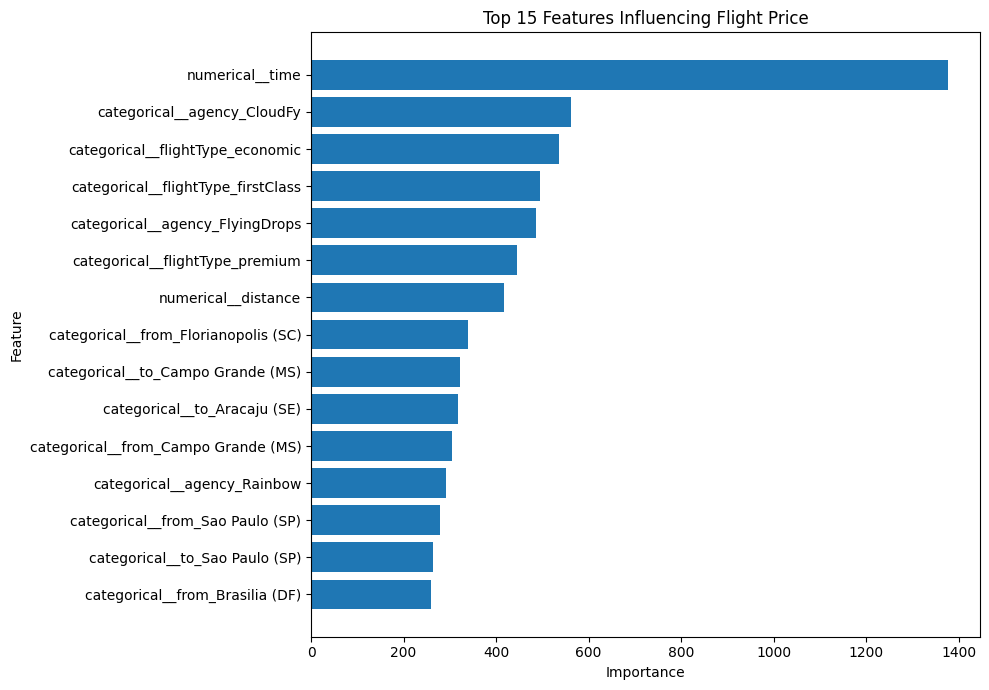

In [83]:
# ==============================
# Top Feature Importance
# ==============================

top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Features Influencing Flight Price")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 15. Error Analysis

The final candidate model is evaluated not only through aggregate metrics but also by examining the distribution and magnitude of prediction errors.

In [84]:
# ==============================
# Error Analysis
# ==============================

error_df = X_group_test.copy()

error_df["actual_price"] = y_group_test.values
error_df["predicted_price"] = y_pred_lgbm
error_df["absolute_error"] = (
    error_df["actual_price"] - error_df["predicted_price"]
).abs()

error_df["percentage_error"] = (
    error_df["absolute_error"] /
    error_df["actual_price"] * 100
)

error_df.head()

,from,to,flightType,time,distance,agency,year,month,day,day_of_week,actual_price,predicted_price,absolute_error,percentage_error
0,Recife (PE),Florianopolis (SC),firstClass,1.76,676.53,FlyingDrops,2019,9,26,3,1434.38,1396.532338,37.847662,2.638608
2,Brasilia (DF),Florianopolis (SC),firstClass,1.66,637.56,CloudFy,2019,10,3,3,1487.52,1592.703209,105.183209,7.071045
16,Recife (PE),Sao Paulo (SP),economic,1.26,486.52,CloudFy,2019,11,21,3,513.06,515.097684,2.037684,0.397163
17,Sao Paulo (SP),Recife (PE),economic,1.26,486.52,CloudFy,2019,11,24,6,829.91,799.644182,30.265818,3.646880
18,Brasilia (DF),Campo Grande (MS),economic,0.72,277.70,CloudFy,2019,11,28,3,583.60,627.995189,44.395189,7.607126


In [85]:
print("Mean absolute error:",
      error_df["absolute_error"].mean())

print("Median absolute error:",
      error_df["absolute_error"].median())

print("Maximum absolute error:",
      error_df["absolute_error"].max())

print("90th percentile absolute error:",
      error_df["absolute_error"].quantile(0.90))

Mean absolute error: 41.728973267260685
Median absolute error: 37.84766182175804
Maximum absolute error: 184.46673263824346
90th percentile absolute error: 87.21648398637421


In [86]:
worst_predictions = (
    error_df
    .sort_values("absolute_error", ascending=False)
    .head(20)
)

worst_predictions[
    [
        "from",
        "to",
        "flightType",
        "agency",
        "time",
        "distance",
        "actual_price",
        "predicted_price",
        "absolute_error",
        "percentage_error"
    ]
]

,from,to,flightType,agency,time,distance,actual_price,predicted_price,absolute_error,percentage_error
38479,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933
12545,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933
7451,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933
34981,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933
55971,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933
89223,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933
39555,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933
58093,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933
2769,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933
25443,Salvador (BH),Brasilia (DF),premium,CloudFy,1.76,676.56,836.89,1021.356733,184.466733,22.041933


## 16. Group-Level Error Analysis

Because the dataset contains repeated observations of the same flight configuration, error analysis is performed both at the observation level and at the unique flight-configuration level.

In [87]:
# ==============================
# Group-Level Error Analysis
# ==============================

error_df["flight_group"] = (
    error_df[
        ["from", "to", "flightType", "agency", "time", "distance"]
    ]
    .astype(str)
    .agg(" | ".join, axis=1)
)

group_error_summary = (
    error_df
    .groupby("flight_group")
    .agg(
        mean_absolute_error=("absolute_error", "mean"),
        max_absolute_error=("absolute_error", "max"),
        mean_percentage_error=("percentage_error", "mean"),
        observations=("absolute_error", "size")
    )
    .sort_values(
        "mean_absolute_error",
        ascending=False
    )
    .reset_index()
)

group_error_summary.head(15)

,flight_group,mean_absolute_error,max_absolute_error,mean_percentage_error,observations
0,Salvador (BH) | Brasilia (DF) | premium | Clou...,184.466733,184.466733,22.041933,278
1,Salvador (BH) | Brasilia (DF) | premium | Rain...,162.232736,162.232736,18.375817,295
2,Salvador (BH) | Sao Paulo (SP) | firstClass | ...,150.837143,150.837143,25.523223,108
3,Brasilia (DF) | Natal (RN) | firstClass | Clou...,124.718184,124.718184,9.493224,434
4,Rio de Janeiro (RJ) | Aracaju (SE) | firstClas...,115.861461,115.861461,8.010333,391
5,Natal (RN) | Sao Paulo (SP) | firstClass | Clo...,112.874871,112.874871,11.061609,271
6,Sao Paulo (SP) | Salvador (BH) | firstClass | ...,111.021794,111.021794,8.495699,108
7,Brasilia (DF) | Florianopolis (SC) | firstClas...,105.183209,105.183209,7.071045,1116
8,Salvador (BH) | Recife (PE) | firstClass | Rai...,100.993525,100.993525,7.012222,266
9,Florianopolis (SC) | Brasilia (DF) | premium |...,89.963678,89.963678,11.044586,1132


In [88]:
# Number of unique flight configurations in the test set

print(
    "Unique test configurations:",
    group_error_summary["flight_group"].nunique()
)

print(
    "Average observations per configuration:",
    round(
        group_error_summary["observations"].mean(),
        2
    )
)

Unique test configurations: 98
Average observations per configuration: 516.47


In [89]:
group_error_summary.head(10)

,flight_group,mean_absolute_error,max_absolute_error,mean_percentage_error,observations
0,Salvador (BH) | Brasilia (DF) | premium | Clou...,184.466733,184.466733,22.041933,278
1,Salvador (BH) | Brasilia (DF) | premium | Rain...,162.232736,162.232736,18.375817,295
2,Salvador (BH) | Sao Paulo (SP) | firstClass | ...,150.837143,150.837143,25.523223,108
3,Brasilia (DF) | Natal (RN) | firstClass | Clou...,124.718184,124.718184,9.493224,434
4,Rio de Janeiro (RJ) | Aracaju (SE) | firstClas...,115.861461,115.861461,8.010333,391
5,Natal (RN) | Sao Paulo (SP) | firstClass | Clo...,112.874871,112.874871,11.061609,271
6,Sao Paulo (SP) | Salvador (BH) | firstClass | ...,111.021794,111.021794,8.495699,108
7,Brasilia (DF) | Florianopolis (SC) | firstClas...,105.183209,105.183209,7.071045,1116
8,Salvador (BH) | Recife (PE) | firstClass | Rai...,100.993525,100.993525,7.012222,266
9,Florianopolis (SC) | Brasilia (DF) | premium |...,89.963678,89.963678,11.044586,1132


## 16.1 Actual vs Predicted

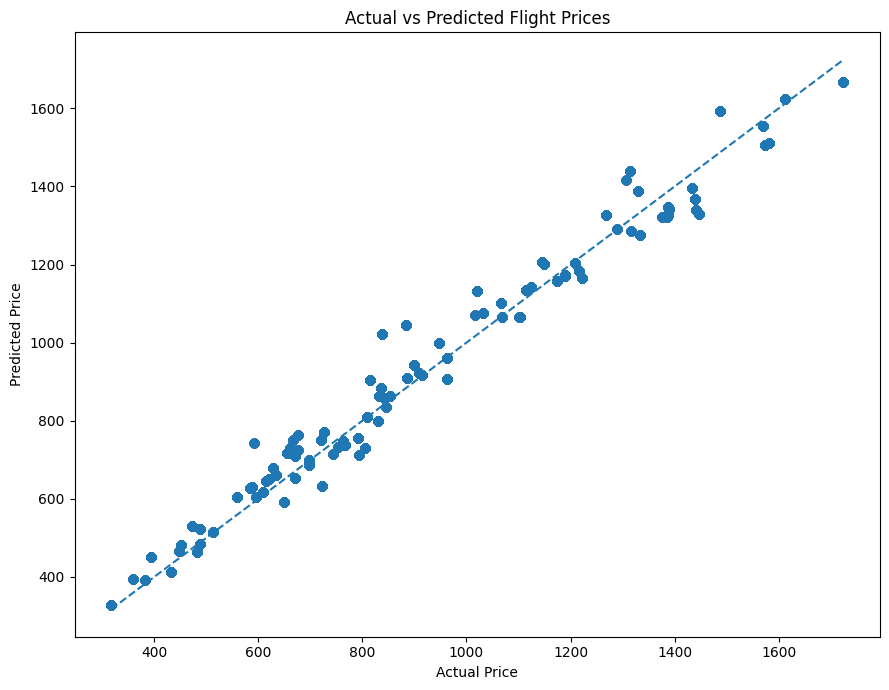

In [90]:
# ==============================
# Actual vs Predicted
# ==============================

plt.figure(figsize=(9, 7))

plt.scatter(
    y_group_test,
    y_pred_lgbm,
    alpha=0.3
)

min_value = min(
    y_group_test.min(),
    y_pred_lgbm.min()
)

max_value = max(
    y_group_test.max(),
    y_pred_lgbm.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Flight Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.tight_layout()
plt.show()

## 16.2  Residual analysis

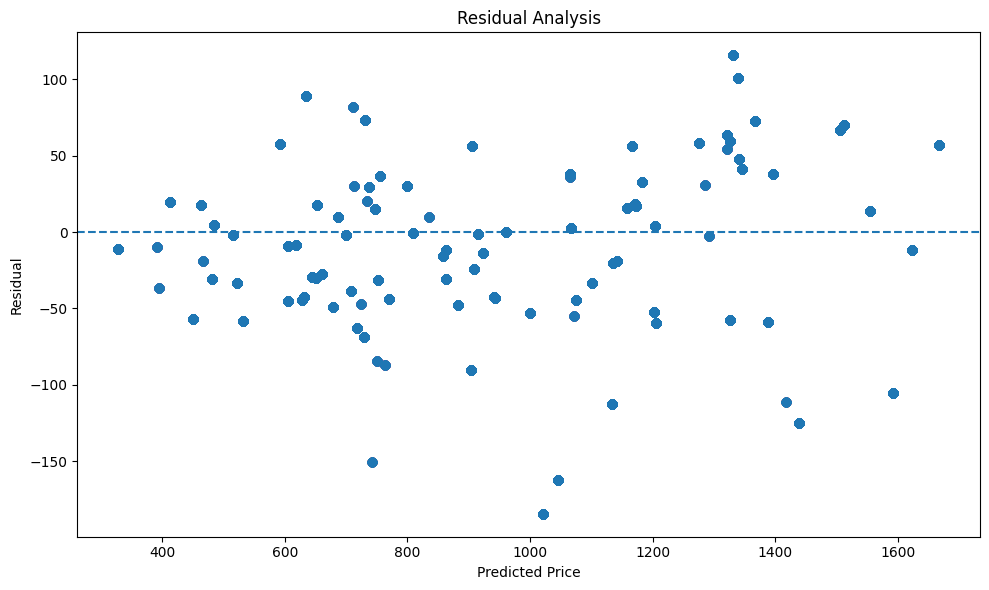

In [91]:
# ==============================
# Residual Analysis
# ==============================

residuals = (
    y_group_test.values - y_pred_lgbm
)

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_lgbm,
    residuals,
    alpha=0.3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residual Analysis")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

## 17. Final Production Pipeline

The final LightGBM configuration is retrained on the complete available dataset after the evaluation set has been used to select the model. The preprocessing and model are combined into a single pipeline to ensure consistent transformations during deployment.

In [92]:
# ==============================
# Final Production Model
# ==============================

final_lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_lgbm)
    ]
)

print("Final production pipeline created.")

Final production pipeline created.


In [93]:
# ==============================
# Train Final Production Model
# ==============================

final_pipeline.fit(X, y)

print("Final production model trained successfully.")

Final production model trained successfully.


In [94]:
# ==============================
# Production Pipeline Test
# ==============================

sample_predictions = final_pipeline.predict(
    X.head(10)
)

print("Sample predictions:")
print(sample_predictions)

Sample predictions:
[1429.44962416 1284.14588538 1499.52786538 1126.20825264 1685.92946058
 1529.99304446  748.6904591   874.62003724  801.70863672  691.59186119]


In [95]:
import joblib

MODEL_PATH = BASE_DIR / "models" / "flight_price_pipeline.joblib"

joblib.dump(
    final_pipeline,
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)
print("File exists:", MODEL_PATH.exists())

Model saved to:
c:\Users\VINAY\Desktop\Labmentix Projects\Travel_MLops_Major_Project\models\flight_price_pipeline.joblib
File exists: True


In [96]:
# ==============================
# Reload Saved Pipeline
# ==============================

loaded_pipeline = joblib.load(MODEL_PATH)

reloaded_predictions = loaded_pipeline.predict(
    X.head(10)
)

print("Saved model loaded successfully.")
print("Predictions match:",
      np.allclose(
          sample_predictions,
          reloaded_predictions
      ))

Saved model loaded successfully.
Predictions match: True


In [1]:
import sys
import mlflow

print("Python:", sys.executable)
print("MLflow:", mlflow.__version__)

Python: c:\Users\VINAY\Desktop\Labmentix Projects\Travel_MLops_Major_Project\.venv\Scripts\python.exe
MLflow: 3.15.1


## 18. MLflow Experiment Tracking

In [2]:
# ==============================
# MLflow Configuration
# ==============================

import mlflow

MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

mlflow.set_experiment(
    "Voyage Analytics - Flight Price Prediction"
)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", mlflow.get_experiment_by_name(
    "Voyage Analytics - Flight Price Prediction"
).name)

2026/08/25 19:56:56 INFO mlflow.tracking.fluent: Experiment with name 'Voyage Analytics - Flight Price Prediction' does not exist. Creating a new experiment.


Tracking URI: http://127.0.0.1:5000
Experiment: Voyage Analytics - Flight Price Prediction


In [3]:
# ==============================
# MLflow Connection Test
# ==============================

with mlflow.start_run(run_name="MLflow_Connection_Test"):

    mlflow.log_param("project", "Voyage Analytics")
    mlflow.log_param("module", "Flight Price Prediction")
    mlflow.log_param(
        "validation_strategy",
        "Group-based unseen configuration split"
    )

    mlflow.log_metric("test_metric", 1.0)

    print("MLflow test run logged successfully.")

MLflow test run logged successfully.
🏃 View run MLflow_Connection_Test at: http://127.0.0.1:5000/#/experiments/1/runs/34804a0b760c461a958729d172358cf1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [1]:
# ==============================
# MLflow - Linear Regression
# ==============================

with mlflow.start_run(run_name="Linear_Regression"):

    mlflow.log_params({
        "model": "LinearRegression",
        "validation_strategy": "Group-based unseen configuration split",
        "test_size": 0.20,
        "features": ", ".join(X.columns.tolist())
    })

    mlflow.log_metrics({
        "MAE": mae_lr_group,
        "RMSE": rmse_lr_group,
        "R2": r2_lr_group
    })

    print("Linear Regression run logged.")

NameError: name 'mlflow' is not defined